# Vietnam Traffic Sign Recognition — CNN Training Notebook

Notebook nay huan luyen CNN cho bai toan phan loai bien bao giao thong Viet Nam.

**Pipeline tong quan:**

```text
Anh dau vao -> Resize -> Normalize -> Data Augmentation -> CNN -> Evaluate
```

Notebook tap trung vao cac buoc co y nghia de giai thich CNN: anh goc, tien xu ly, feature map, Grad-CAM.

## 1. Import thu vien

Thu vien chinh:
- tensorflow/keras: xay dung va huan luyen CNN
- opencv: tien xu ly va minh hoa feature
- scikit-learn: metrics, confusion matrix

In [17]:
import os
import random
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

def read_image_rgb(path, img_size=None):
    path = str(path)
    img_bytes = tf.io.read_file(path)
    img = tf.image.decode_image(img_bytes, channels=3, expand_animations=False)
    if img_size is not None:
        img = tf.image.resize(img, [img_size, img_size])
    img = tf.clip_by_value(img, 0, 255)
    img = tf.cast(img, tf.uint8).numpy()
    return img

def is_readable_image(path):
    try:
        _ = read_image_rgb(path, img_size=None)
        return True
    except Exception:
        return False

print("Imports OK. TensorFlow:", tf.__version__)

Imports OK. TensorFlow: 2.14.0


## 2. Chon duong dan dataset

In [18]:
CLASSES = ["Cam", "Chidan", "Hieulenh", "Nguyhiem", "Phu"]

ROOT_DIR = Path(".").resolve()
if (ROOT_DIR / "data").is_dir():
    DATA_DIR = ROOT_DIR / "data"
else:
    DATA_DIR = ROOT_DIR.parent / "data"

TRAIN_DIR = DATA_DIR / "train"
TEST_DIR = DATA_DIR / "test"

print("TRAIN_DIR:", TRAIN_DIR)
print("TEST_DIR :", TEST_DIR)
print("Train dir exists:", TRAIN_DIR.exists())
print("Test dir exists :", TEST_DIR.exists())

TRAIN_DIR: E:\CS-UIT\Ki 6\Nhập môn CV\CS231.Q22-TrafficSign-Classification\data\train
TEST_DIR : E:\CS-UIT\Ki 6\Nhập môn CV\CS231.Q22-TrafficSign-Classification\data\test
Train dir exists: True
Test dir exists : True


## 3. Kiem tra so luong anh theo tung lop

Train set:


,class,num_images
0,Cam,325
1,Chidan,283
2,Hieulenh,266
3,Nguyhiem,268
4,Phu,202


Test set:


,class,num_images
0,Cam,36
1,Chidan,36
2,Hieulenh,31
3,Nguyhiem,29
4,Phu,23


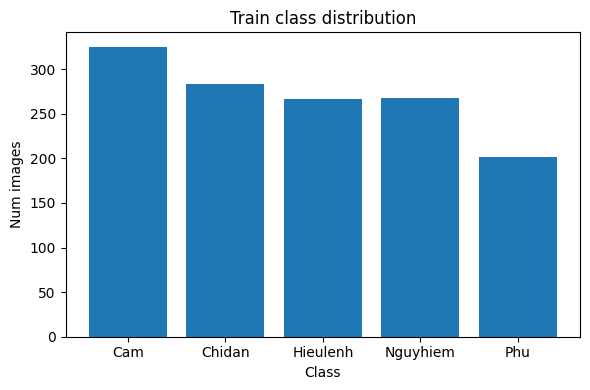

Total train: 1344
Total test : 155


In [19]:
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def count_images_by_class(data_dir, classes=CLASSES):
    rows = []
    data_dir = Path(data_dir)
    for cls in classes:
        cls_dir = data_dir / cls
        files = [p for p in cls_dir.rglob("*") if p.suffix.lower() in IMG_EXTS]
        rows.append({"class": cls, "num_images": len(files)})
    return pd.DataFrame(rows)

train_count = count_images_by_class(TRAIN_DIR)
test_count = count_images_by_class(TEST_DIR)

print("Train set:")
display(train_count)
print("Test set:")
display(test_count)

plt.figure(figsize=(6, 4))
plt.bar(train_count["class"], train_count["num_images"])
plt.title("Train class distribution")
plt.xlabel("Class")
plt.ylabel("Num images")
plt.tight_layout()
plt.show()

print("Total train:", train_count["num_images"].sum())
print("Total test :", test_count["num_images"].sum())

## 4. Hien thi anh mau theo lop

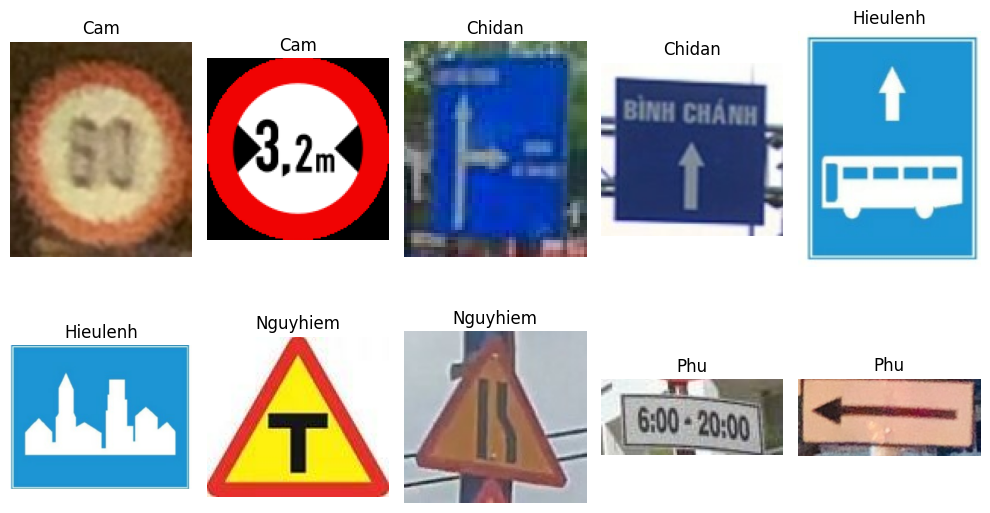

In [20]:
def get_image_paths(data_dir, classes=CLASSES):
    image_paths = []
    labels = []
    data_dir = Path(data_dir)
    for label, cls in enumerate(classes):
        cls_dir = data_dir / cls
        files = sorted([p for p in cls_dir.rglob("*") if p.suffix.lower() in IMG_EXTS])
        image_paths.extend(files)
        labels.extend([label] * len(files))
    return image_paths, np.array(labels)

train_paths, y_train = get_image_paths(TRAIN_DIR)
test_paths, y_test = get_image_paths(TEST_DIR)

samples = []
for cls in CLASSES:
    cls_paths = [p for p in train_paths if p.parent.name == cls]
    if cls_paths:
        samples.extend(random.sample(cls_paths, k=min(2, len(cls_paths))))

plt.figure(figsize=(10, 6))
skipped = 0
plot_idx = 1
for path in samples:
    try:
        img = read_image_rgb(path)
    except Exception:
        skipped += 1
        continue
    plt.subplot(2, 5, plot_idx)
    plt.imshow(img)
    plt.title(path.parent.name)
    plt.axis("off")
    plot_idx += 1

plt.tight_layout()
plt.show()
if skipped > 0:
    print(f"Skipped {skipped} unreadable images in samples.")

## 5. Tien xu ly va kiem tra feature (de hieu CNN se nhin gi)

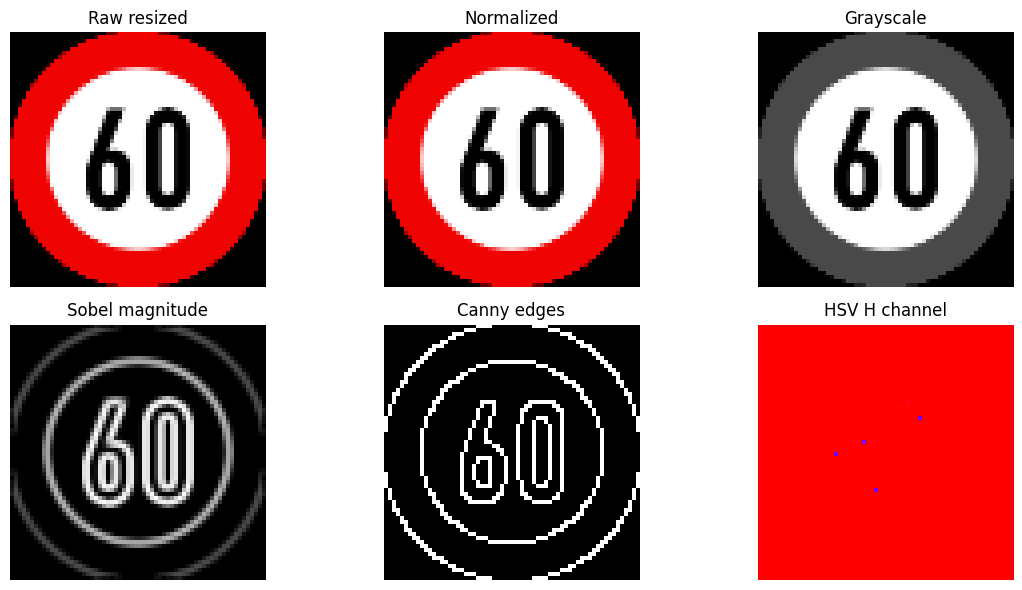

In [21]:
IMG_SIZE = 64

def find_readable_path(paths):
    for p in paths:
        if is_readable_image(p):
            return p
    return None

sample_path = find_readable_path(train_paths)
if sample_path is None:
    raise ValueError("No readable images found in train_paths.")
img = read_image_rgb(sample_path, IMG_SIZE)

img_norm = img.astype("float32") / 255.0
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
sobelx = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=3)
sobely = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=3)
sobel_mag = cv2.magnitude(sobelx, sobely)
sobel_mag = cv2.normalize(sobel_mag, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
canny = cv2.Canny(gray, 80, 160)
hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
h_channel = hsv[:, :, 0]

plt.figure(figsize=(12, 6))
plt.subplot(2, 3, 1)
plt.imshow(img)
plt.title("Raw resized")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(img_norm)
plt.title("Normalized")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(sobel_mag, cmap="gray")
plt.title("Sobel magnitude")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(canny, cmap="gray")
plt.title("Canny edges")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(h_channel, cmap="hsv")
plt.title("HSV H channel")
plt.axis("off")

plt.tight_layout()
plt.show()

## 6. Tao dataset cho train/val/test

In [22]:
from sklearn.model_selection import train_test_split

IMG_SIZE = 64
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

def filter_valid_images(paths, labels):
    keep_paths = []
    keep_labels = []
    skipped = 0
    for p, y in zip(paths, labels):
        if not is_readable_image(p):
            skipped += 1
            continue
        keep_paths.append(str(p))
        keep_labels.append(int(y))
    if skipped > 0:
        print(f"Skipped {skipped} unreadable images.")
    return keep_paths, np.array(keep_labels, dtype=np.int64)

train_paths, y_train = filter_valid_images(train_paths, y_train)
test_paths, y_test = filter_valid_images(test_paths, y_test)

train_paths_new, val_paths, y_train_new, y_val = train_test_split(
    train_paths,
    y_train,
    test_size=0.2,
    random_state=SEED,
    stratify=y_train,
)

def build_dataset(paths, labels, training):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(buffer_size=len(paths), seed=SEED, reshuffle_each_iteration=True)
    def decode_img(path, label):
        img_bytes = tf.io.read_file(path)
        img = tf.image.decode_image(img_bytes, channels=3, expand_animations=False)
        img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
        img = tf.cast(img, tf.float32)
        img.set_shape((IMG_SIZE, IMG_SIZE, 3))
        label = tf.cast(label, tf.int32)
        return img, label
    ds = ds.map(decode_img, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = build_dataset(train_paths_new, y_train_new, training=True)
val_ds = build_dataset(val_paths, y_val, training=False)
test_ds = build_dataset(test_paths, y_test, training=False)

print("Class order:", CLASSES)
print(f"Train/Val/Test: {len(train_paths_new)}/{len(val_paths)}/{len(test_paths)}")

Class order: ['Cam', 'Chidan', 'Hieulenh', 'Nguyhiem', 'Phu']
Train/Val/Test: 1075/269/155


## 7. Data augmentation (co y nghia cho tong quat hoa)

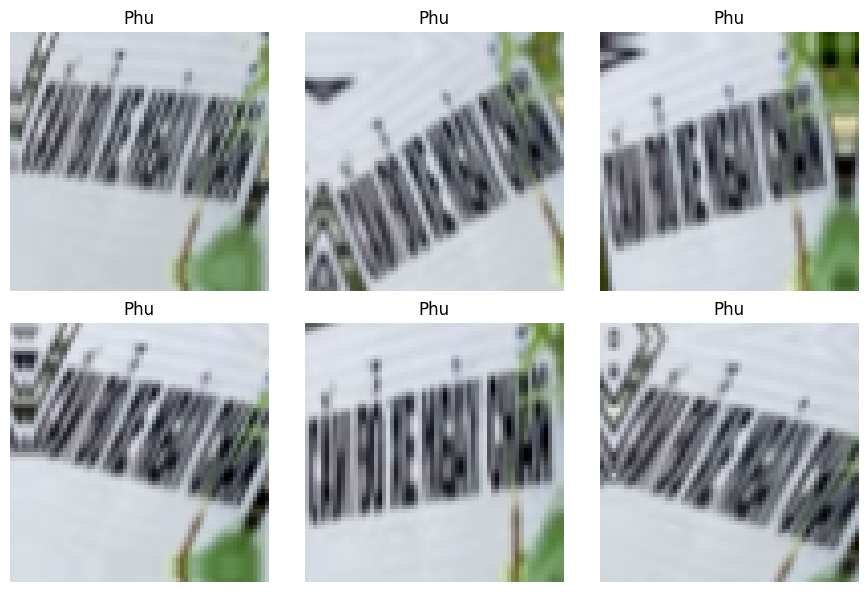

In [23]:
data_augmentation = keras.Sequential(
    [
        layers.RandomRotation(0.08),
        layers.RandomZoom(0.1),
        layers.RandomTranslation(0.08, 0.08),
        layers.RandomContrast(0.15),
    ],
    name="data_augmentation",
)

for images, labels in train_ds.take(1):
    sample_img = images[0]
    sample_label = labels[0].numpy()

plt.figure(figsize=(9, 6))
for i in range(6):
    aug_img = data_augmentation(tf.expand_dims(sample_img, 0), training=True)
    plt.subplot(2, 3, i + 1)
    plt.imshow(tf.cast(aug_img[0], tf.uint8))
    plt.title(CLASSES[sample_label])
    plt.axis("off")
plt.tight_layout()
plt.show()

## 8. Xay dung CNN model

In [24]:
NUM_CLASSES = len(CLASSES)
USE_TRANSFER = True
try:
    loss_fn = keras.losses.SparseCategoricalCrossentropy(label_smoothing=0.05)
except TypeError:
    # Older Keras builds do not support label_smoothing for sparse labels.
    loss_fn = keras.losses.SparseCategoricalCrossentropy()

if USE_TRANSFER:
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,
        weights="imagenet",
    )
    base_model.trainable = False

    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = data_augmentation(inputs)
    x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax", name="predictions")(x)
    model = keras.Model(inputs, outputs)
else:
    model = keras.Sequential(
        [
            layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
            data_augmentation,
            layers.Rescaling(1.0 / 255),
            layers.Conv2D(32, 3, padding="same", activation="relu", name="conv1"),
            layers.BatchNormalization(),
            layers.MaxPooling2D(),
            layers.Conv2D(64, 3, padding="same", activation="relu", name="conv2"),
            layers.BatchNormalization(),
            layers.MaxPooling2D(),
            layers.Conv2D(128, 3, padding="same", activation="relu", name="conv3"),
            layers.BatchNormalization(),
            layers.MaxPooling2D(),
            layers.Dropout(0.3),
            layers.Flatten(),
            layers.Dense(256, activation="relu", name="dense_features"),
            layers.Dropout(0.4),
            layers.Dense(NUM_CLASSES, activation="softmax", name="predictions"),
        ]
    )

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=loss_fn,
    metrics=["accuracy"],
)

model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_4 (InputLayer)        [(None, 64, 64, 3)]       0         
                                                                 
 data_augmentation (Sequent  (None, 64, 64, 3)         0         
 ial)                                                            
                                                                 
 tf.math.truediv_1 (TFOpLam  (None, 64, 64, 3)         0         
 bda)                                                            
                                                                 
 tf.math.subtract_1 (TFOpLa  (None, 64, 64, 3)         0         
 mbda)                                                           
                                                                 
 mobilenetv2_1.00_224 (Func  (None, 2, 2, 1280)        2257984   
 tional)                                                     

## 9. Huan luyen CNN

In [25]:
train_labels = y_train_new
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_CLASSES),
    y=train_labels,
)
class_weight = {i: float(w) for i, w in enumerate(class_weights)}
print("Class weights:", class_weight)

ROOT_DIR = Path(".").resolve()
CNN_DIR = ROOT_DIR / "cnn"
if not CNN_DIR.is_dir():
    CNN_DIR = ROOT_DIR

MODELS_DIR = CNN_DIR / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
checkpoint_path = str(MODELS_DIR / "cnn_model.weights.h5")

callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=5, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6),
    keras.callbacks.ModelCheckpoint(
        checkpoint_path,
        monitor="val_accuracy",
        save_best_only=True,
        save_weights_only=True,
    ),
]

history_warmup = None
history_finetune = None

EPOCHS_WARMUP = 15
history_warmup = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_WARMUP,
    class_weight=class_weight,
    callbacks=callbacks,
 )

if USE_TRANSFER:
    base_model.trainable = True
    fine_tune_at = max(0, len(base_model.layers) - 40)
    for layer in base_model.layers[:fine_tune_at]:
        layer.trainable = False
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-4),
        loss=loss_fn,
        metrics=["accuracy"],
    )
    EPOCHS_FINE = 10
    history_finetune = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS_FINE,
        class_weight=class_weight,
        callbacks=callbacks,
    )

Class weights: {0: 0.8269230769230769, 1: 0.9513274336283186, 2: 1.0093896713615023, 3: 1.0046728971962617, 4: 1.3271604938271604}
Epoch 1/15
34/34 [==============================] - 12s 162ms/step - loss: 1.4080 - accuracy: 0.4949 - val_loss: 0.7655 - val_accuracy: 0.6952 - lr: 0.0010
Epoch 2/15
34/34 [==============================] - 4s 118ms/step - loss: 0.7351 - accuracy: 0.7172 - val_loss: 0.5978 - val_accuracy: 0.7658 - lr: 0.0010
Epoch 3/15
34/34 [==============================] - 4s 126ms/step - loss: 0.5776 - accuracy: 0.7730 - val_loss: 0.5494 - val_accuracy: 0.7807 - lr: 0.0010
Epoch 4/15
34/34 [==============================] - 5s 130ms/step - loss: 0.5145 - accuracy: 0.8074 - val_loss: 0.5227 - val_accuracy: 0.7955 - lr: 0.0010
Epoch 5/15
34/34 [==============================] - 5s 137ms/step - loss: 0.4338 - accuracy: 0.8298 - val_loss: 0.4957 - val_accuracy: 0.8178 - lr: 0.0010
Epoch 6/15
34/34 [==============================] - 3s 89ms/step - loss: 0.4271 - accuracy: 0

## 10. Training curves (loss/accuracy)

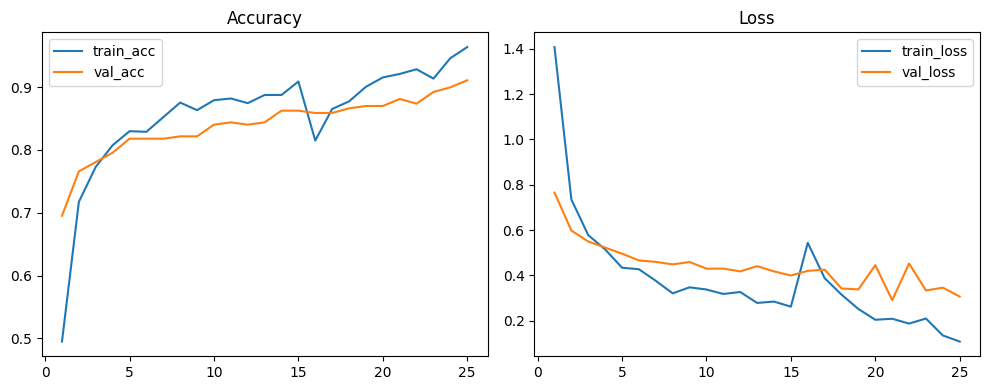

Saved training curves to: E:\CS-UIT\Ki 6\Nhập môn CV\CS231.Q22-TrafficSign-Classification\cnn\cnn_training_curves.png


In [26]:
def merge_histories(h1, h2):
    hist = {}
    for k in h1.history:
        hist[k] = h1.history[k] + (h2.history[k] if h2 is not None else [])
    return hist

history_all = merge_histories(history_warmup, history_finetune)
epochs_range = range(1, len(history_all["loss"]) + 1)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history_all["accuracy"], label="train_acc")
plt.plot(epochs_range, history_all["val_accuracy"], label="val_acc")
plt.title("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history_all["loss"], label="train_loss")
plt.plot(epochs_range, history_all["val_loss"], label="val_loss")
plt.title("Loss")
plt.legend()

plt.tight_layout()
curves_path = CNN_DIR / "cnn_training_curves.png"
plt.savefig(curves_path, dpi=200, bbox_inches="tight")
plt.show()
print("Saved training curves to:", curves_path)

## 11. Danh gia tren val/test va in metrics

In [27]:
val_loss, val_acc = model.evaluate(val_ds, verbose=0)
test_loss, test_acc = model.evaluate(test_ds, verbose=0)

print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Test Accuracy      : {test_acc:.4f}")

y_true = np.concatenate([y.numpy() for _, y in test_ds], axis=0)
y_probs = model.predict(test_ds)
y_pred = np.argmax(y_probs, axis=1)

print("Test Classification Report:")
print(classification_report(y_true, y_pred, target_names=CLASSES, digits=4))

Validation Accuracy: 0.9108
Test Accuracy      : 0.9097
5/5 [==============================] - 1s 65ms/step
Test Classification Report:
              precision    recall  f1-score   support

         Cam     0.9474    1.0000    0.9730        36
      Chidan     0.8049    0.9167    0.8571        36
    Hieulenh     0.9231    0.7742    0.8421        31
    Nguyhiem     1.0000    1.0000    1.0000        29
         Phu     0.9048    0.8261    0.8636        23

    accuracy                         0.9097       155
   macro avg     0.9160    0.9034    0.9072       155
weighted avg     0.9129    0.9097    0.9087       155



## 12. Confusion Matrix

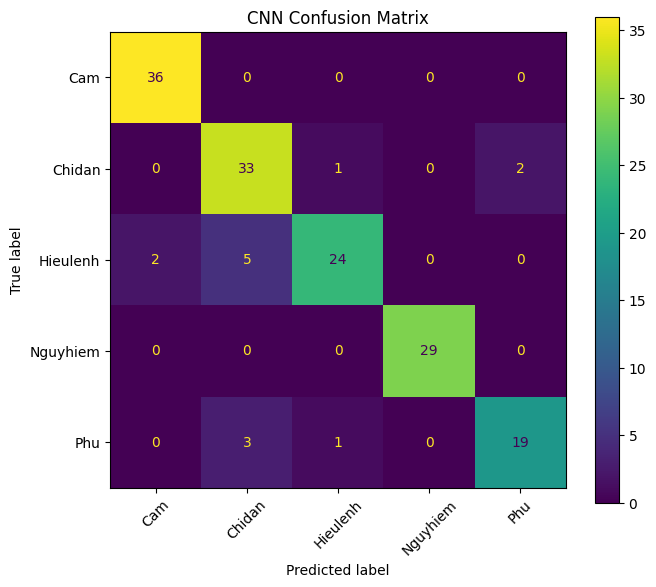

Saved confusion matrix to: E:\CS-UIT\Ki 6\Nhập môn CV\CS231.Q22-TrafficSign-Classification\cnn\cnn_confusion_matrix.png


In [28]:
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES)
disp.plot(ax=ax, xticks_rotation=45, values_format="d")
plt.title("CNN Confusion Matrix")
plt.tight_layout()
cm_path = CNN_DIR / "cnn_confusion_matrix.png"
plt.savefig(cm_path, dpi=200, bbox_inches="tight")
plt.show()
print("Saved confusion matrix to:", cm_path)

## 13. Luu bao cao va model

In [29]:
report_path = CNN_DIR / "cnn_classification_report.txt"
final_model_path = MODELS_DIR / "cnn_model_final.keras"

report = classification_report(y_true, y_pred, target_names=CLASSES, digits=4)
with open(report_path, "w", encoding="utf-8") as f:
    f.write(f"Test accuracy: {test_acc:.4f}\n\n")
    f.write(report)

model.save(final_model_path)

print("Saved report to:", report_path)
print("Saved final model to:", final_model_path)

Saved report to: E:\CS-UIT\Ki 6\Nhập môn CV\CS231.Q22-TrafficSign-Classification\cnn\cnn_classification_report.txt
Saved final model to: E:\CS-UIT\Ki 6\Nhập môn CV\CS231.Q22-TrafficSign-Classification\cnn\models\cnn_model_final.keras


## 14. Feature maps qua cac lop CNN

Pipeline visualize:
Crop ROI -> Resize 64x64 -> Normalize -> Feature maps conv1/conv2/conv3 -> Predict (softmax) -> Grad-CAM overlay.

1/1 [==============================] - 1s 823ms/step


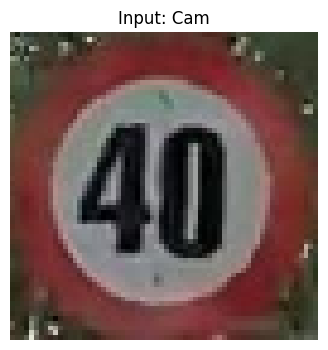

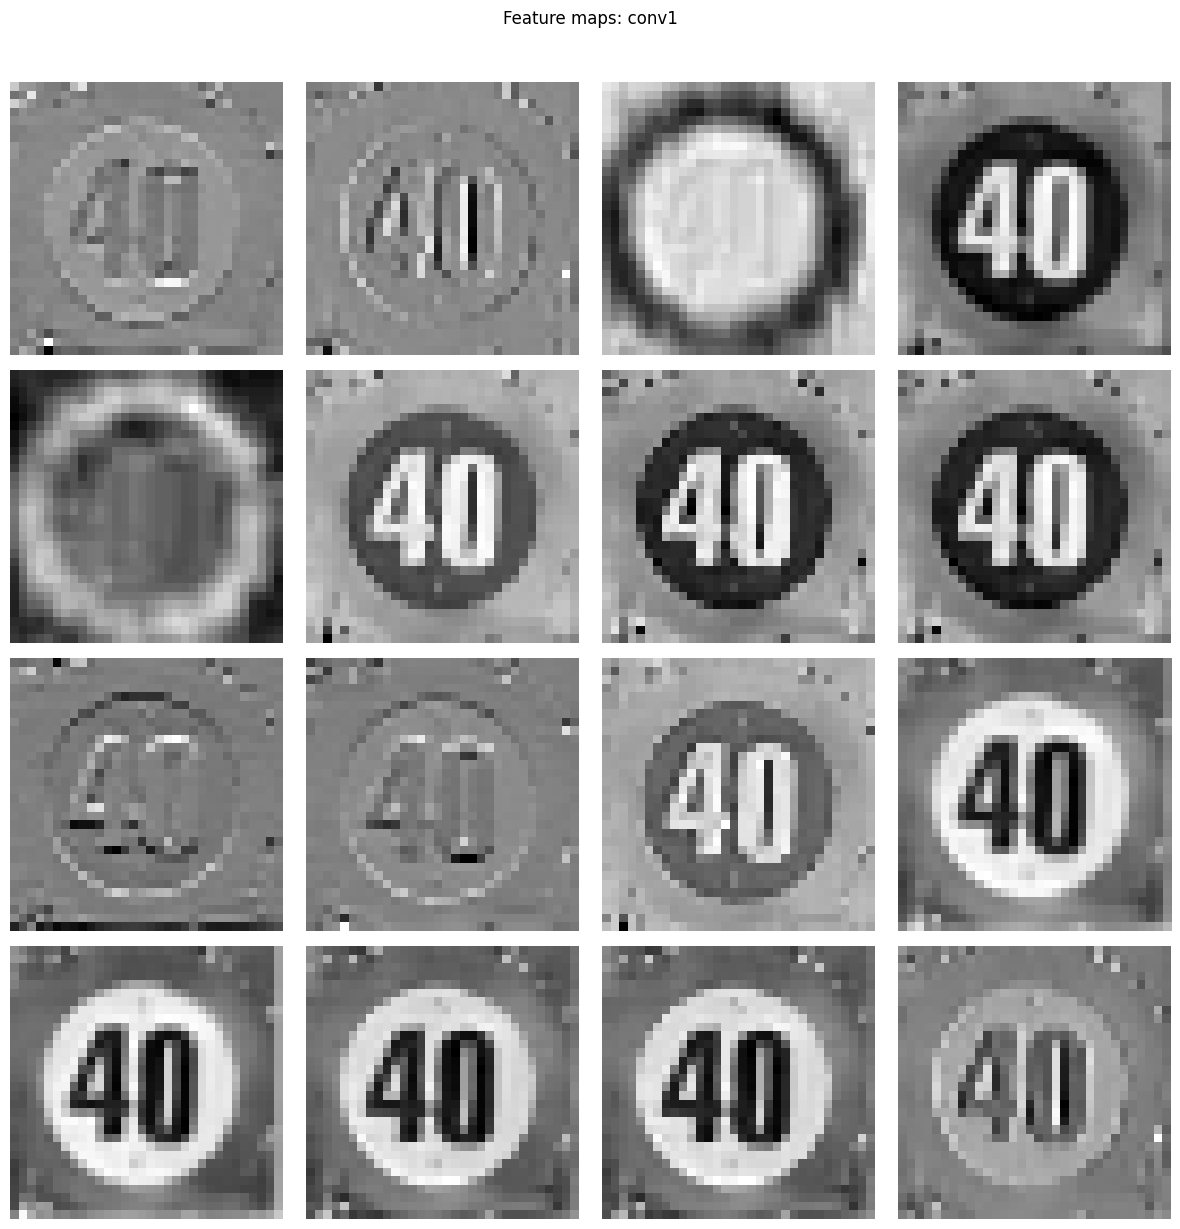

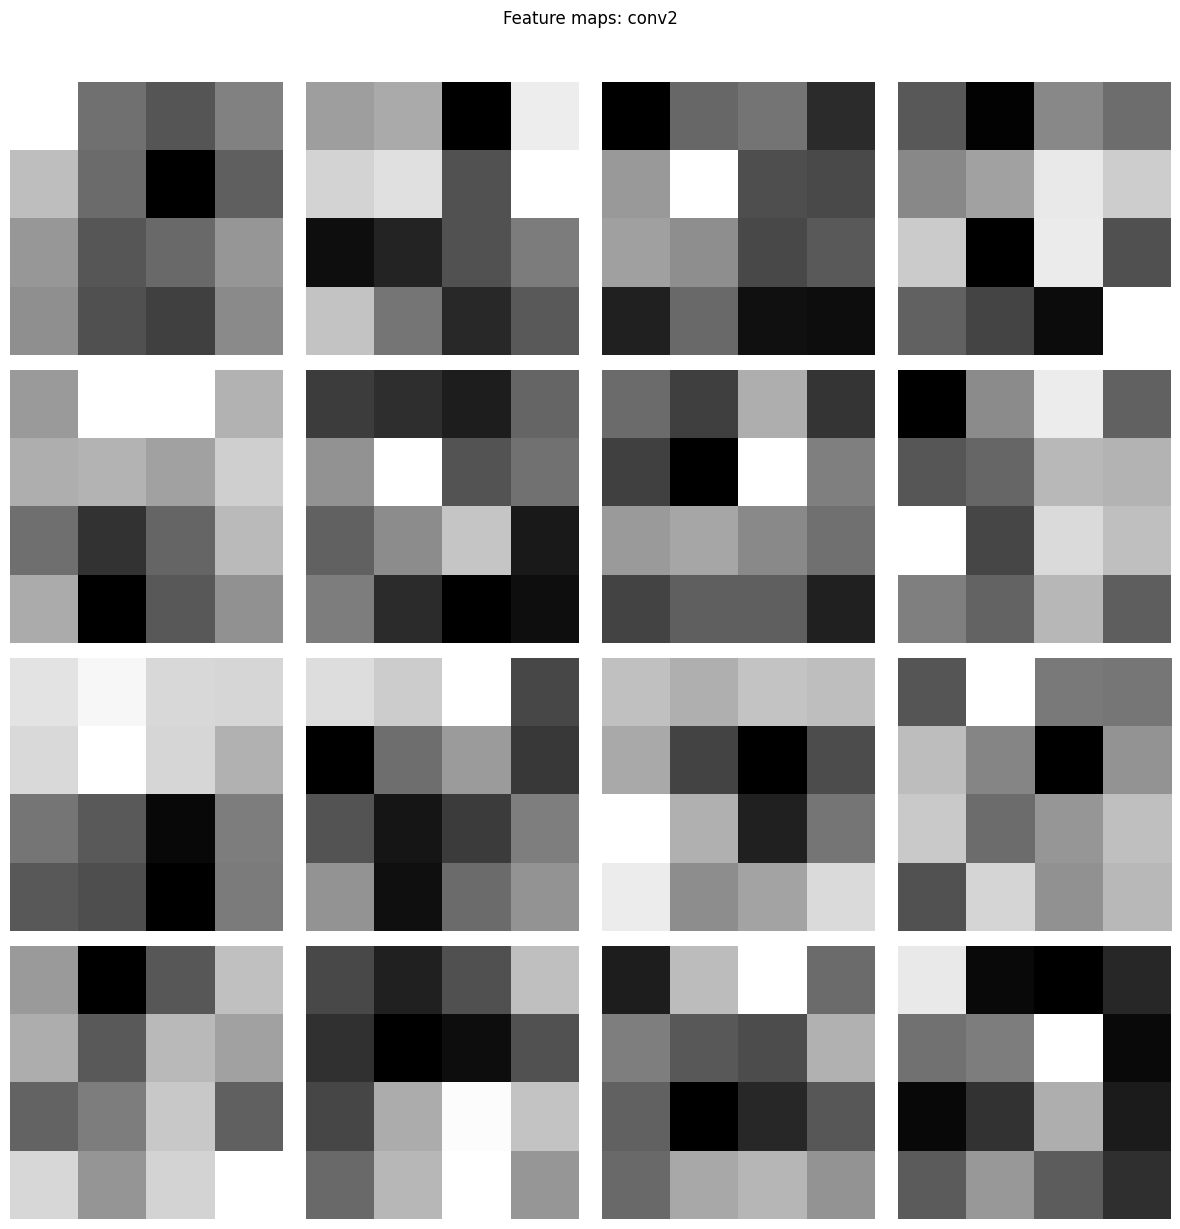

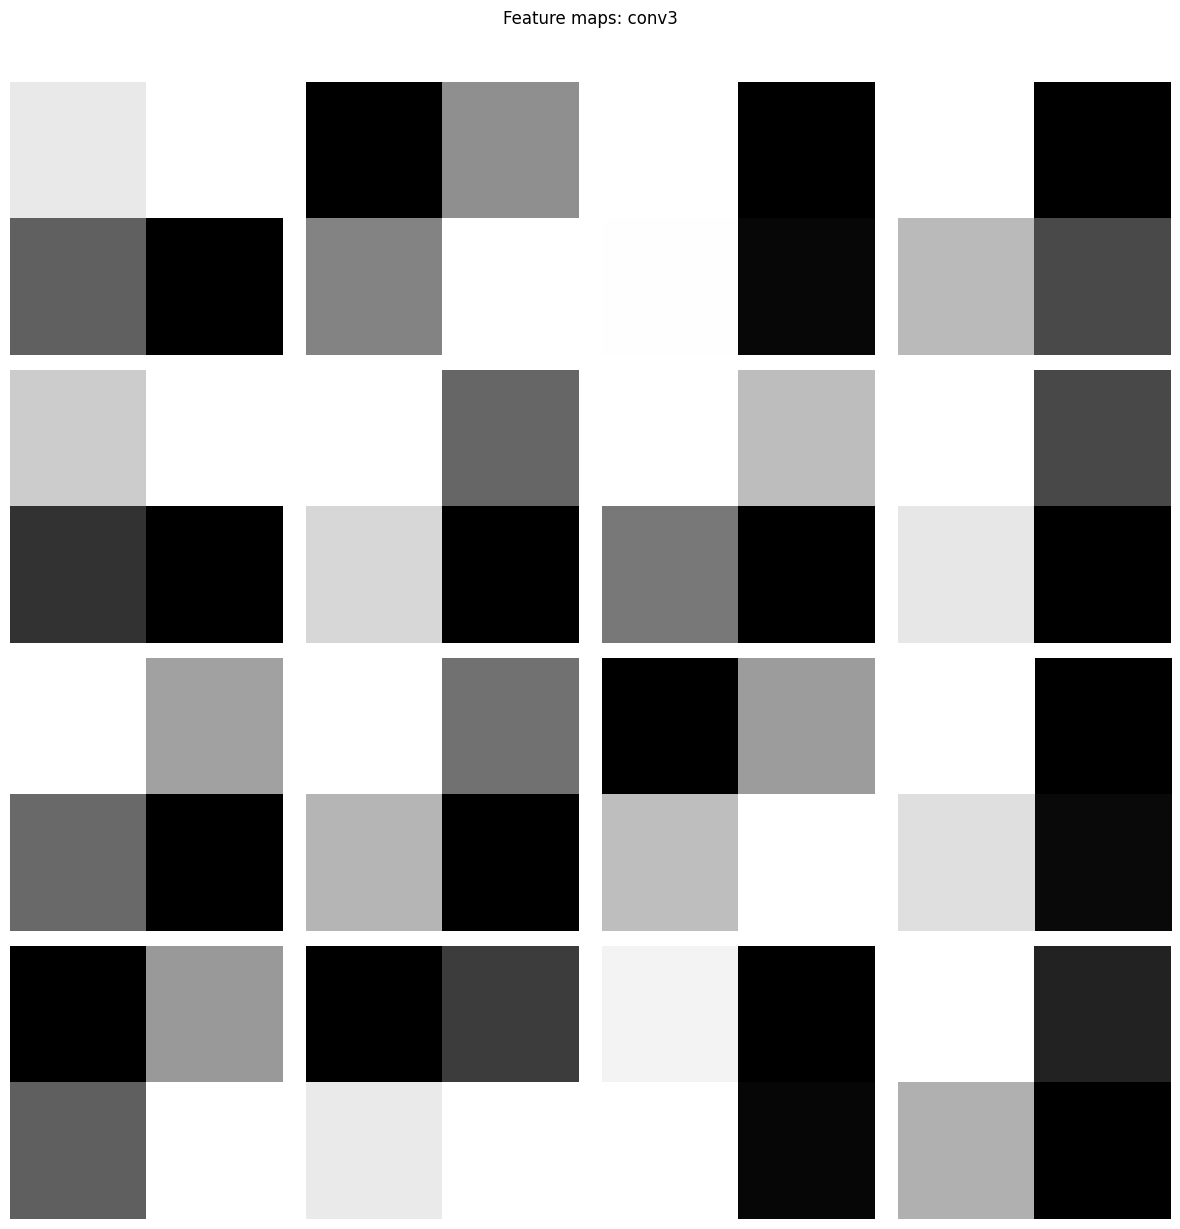

In [31]:
if USE_TRANSFER:
    feature_source = base_model
    conv_candidates = [
        layer.name
        for layer in feature_source.layers
        if isinstance(layer, (layers.Conv2D, layers.DepthwiseConv2D))
    ]
else:
    feature_source = model
    conv_candidates = [
        layer.name
        for layer in feature_source.layers
        if isinstance(layer, layers.Conv2D)
    ]

if len(conv_candidates) >= 3:
    mid_idx = len(conv_candidates) // 2
    conv_layer_names = [conv_candidates[0], conv_candidates[mid_idx], conv_candidates[-1]]
else:
    conv_layer_names = conv_candidates

feature_extractor = keras.Model(
    inputs=feature_source.input,
    outputs=[feature_source.get_layer(name).output for name in conv_layer_names],
)

if len(test_paths) == 0:
    raise ValueError("No test images available.")
sample_path = test_paths[0]
sample_img = keras.utils.load_img(sample_path, target_size=(IMG_SIZE, IMG_SIZE))
sample_arr = keras.utils.img_to_array(sample_img)
sample_batch = np.expand_dims(sample_arr, axis=0)

if USE_TRANSFER:
    sample_batch = tf.keras.applications.mobilenet_v2.preprocess_input(sample_batch)

feature_maps = feature_extractor.predict(sample_batch)

plt.figure(figsize=(4, 4))
plt.imshow(sample_img)
plt.title(f"Input: {Path(sample_path).parent.name}")
plt.axis("off")
plt.show()

def plot_feature_map_grid(feature_map, layer_name, max_channels=16):
    num_channels = feature_map.shape[-1]
    n = min(num_channels, max_channels)
    cols = 4
    rows = int(np.ceil(n / cols))
    plt.figure(figsize=(12, 3 * rows))
    for i in range(n):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(feature_map[:, :, i], cmap="gray")
        plt.axis("off")
    plt.suptitle(f"Feature maps: {layer_name}", y=1.02)
    plt.tight_layout()
    plt.show()

for idx, fmap in enumerate(feature_maps):
    plot_feature_map_grid(fmap[0], f"conv{idx + 1}", max_channels=16)

## 15. Grad-CAM de giai thich vung quan tam

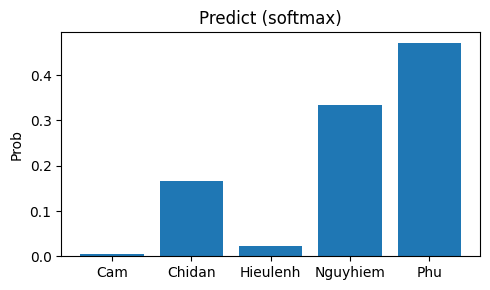

ValueError: Graph disconnected: cannot obtain value for tensor KerasTensor(type_spec=TensorSpec(shape=(None, 64, 64, 3), dtype=tf.float32, name='input_3'), name='input_3', description="created by layer 'input_3'") at layer "Conv1". The following previous layers were accessed without issue: []

In [39]:
def make_gradcam_heatmap(img_array, model, last_conv_output, pred_index=None):
    grad_model = keras.Model(
        [model.inputs],
        [last_conv_output, model.output],
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]
    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(tf.multiply(pooled_grads, conv_outputs), axis=-1)
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), int(pred_index.numpy())

if USE_TRANSFER:
    backbone = model.get_layer(base_model.name)
    last_conv_output = backbone.output
else:
    conv_candidates = [
        layer.name
        for layer in model.layers
        if isinstance(layer, layers.Conv2D)
    ]
    if not conv_candidates:
        raise ValueError("No convolution layers found for Grad-CAM.")
    last_conv_output = model.get_layer(conv_candidates[-1]).output

gradcam_batch = np.expand_dims(sample_arr.astype("float32"), axis=0)
sample_probs = model.predict(gradcam_batch, verbose=0)[0]
pred_idx = int(np.argmax(sample_probs))
pred_label = CLASSES[pred_idx]

plt.figure(figsize=(5, 3))
plt.bar(CLASSES, sample_probs)
plt.title("Predict (softmax)")
plt.ylabel("Prob")
plt.tight_layout()
plt.show()

heatmap, _ = make_gradcam_heatmap(gradcam_batch, model, last_conv_output, pred_index=pred_idx)
heatmap = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))

plt.figure(figsize=(6, 3))
plt.subplot(1, 2, 1)
plt.imshow(sample_img)
plt.title(f"Pred: {pred_label}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(sample_img)
plt.imshow(heatmap, cmap="jet", alpha=0.4)
plt.title("Grad-CAM")
plt.axis("off")
plt.tight_layout()
plt.show()

## 16. Xem cac anh du doan sai

Num wrong predictions: 14


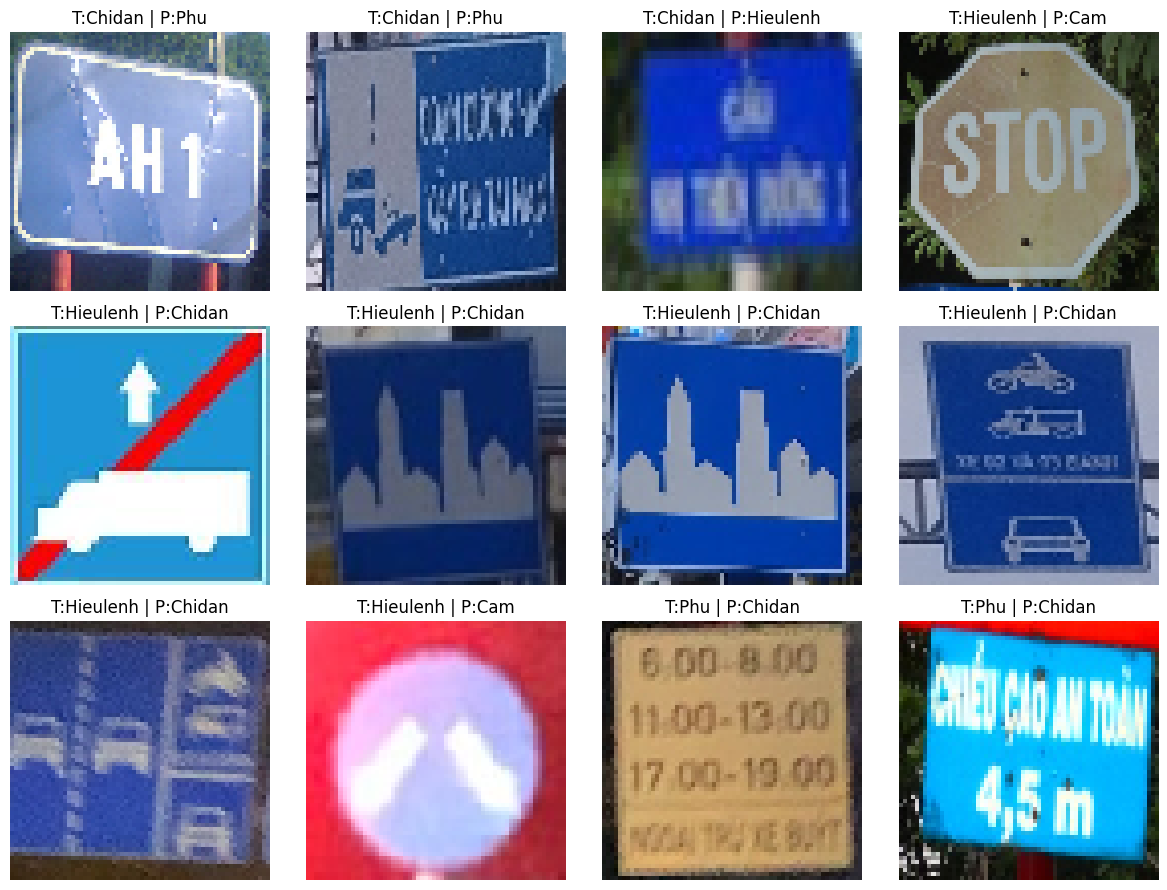

In [36]:
wrong_indices = np.where(y_true != y_pred)[0]
print("Num wrong predictions:", len(wrong_indices))

if len(wrong_indices) > 0:
    show_n = min(12, len(wrong_indices))
    plt.figure(figsize=(12, 9))
    for i, idx in enumerate(wrong_indices[:show_n]):
        path = test_paths[idx]
        img = keras.utils.load_img(path, target_size=(IMG_SIZE, IMG_SIZE))
        plt.subplot(3, 4, i + 1)
        plt.imshow(img)
        true_name = CLASSES[y_true[idx]]
        pred_name = CLASSES[y_pred[idx]]
        plt.title(f"T:{true_name} | P:{pred_name}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("No wrong predictions in test set.")

## 17. Predict thu mot anh bat ky

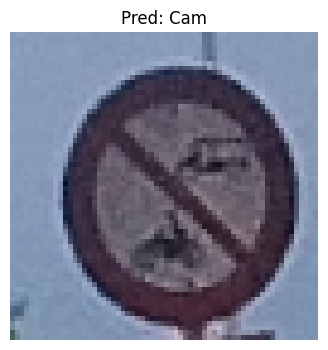

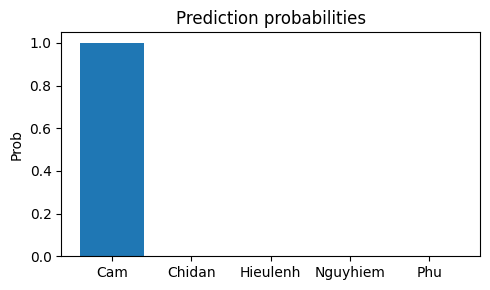

In [37]:
def predict_image(image_path, model=model):
    img = keras.utils.load_img(image_path, target_size=(IMG_SIZE, IMG_SIZE))
    arr = keras.utils.img_to_array(img)
    arr = np.expand_dims(arr, axis=0)
    probs = model.predict(arr, verbose=0)[0]
    pred = int(np.argmax(probs))
    return CLASSES[pred], probs

if len(test_paths) == 0:
    raise ValueError("No test images available.")
image_path = test_paths[2]
pred_class, pred_probs = predict_image(image_path)

plt.figure(figsize=(4, 4))
plt.imshow(keras.utils.load_img(image_path, target_size=(IMG_SIZE, IMG_SIZE)))
plt.title(f"Pred: {pred_class}")
plt.axis("off")
plt.show()

plt.figure(figsize=(5, 3))
plt.bar(CLASSES, pred_probs)
plt.title("Prediction probabilities")
plt.ylabel("Prob")
plt.tight_layout()
plt.show()

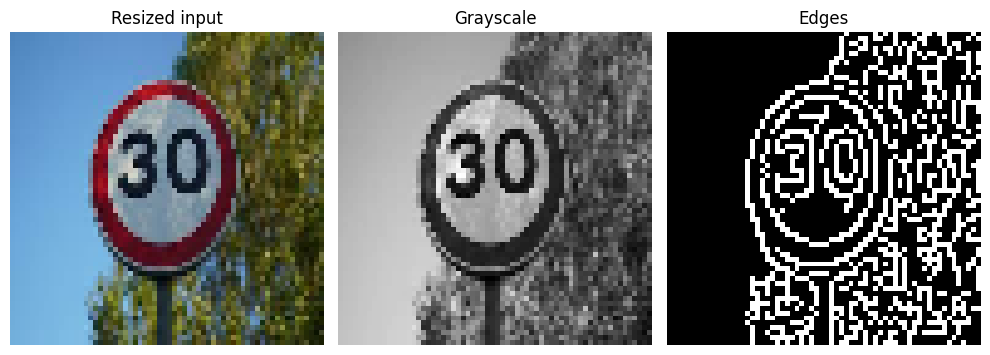

Prediction: Cam


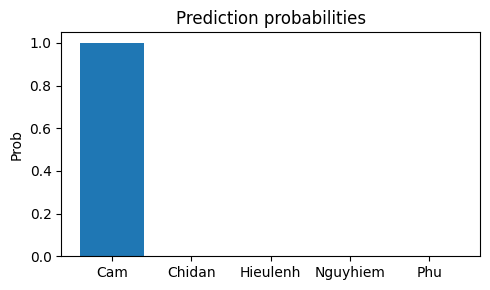

ValueError: No such layer: conv1. Existing layers are: ['input_4', 'data_augmentation', 'tf.math.truediv_1', 'tf.math.subtract_1', 'mobilenetv2_1.00_224', 'global_average_pooling2d_1', 'dropout_1', 'predictions'].

In [40]:
# Custom image path (downloaded from the Internet or local file)
custom_path = r"E:\CS-UIT\Ki 6\Nhập môn CV\CS231.Q22-TrafficSign-Classification\manual-test\images.jpg"

if not os.path.isfile(custom_path):
    raise FileNotFoundError(f"File not found: {custom_path}")

custom_img = read_image_rgb(custom_path, IMG_SIZE)
custom_norm = custom_img.astype("float32") / 255.0
custom_gray = cv2.cvtColor(custom_img, cv2.COLOR_RGB2GRAY)
custom_canny = cv2.Canny(custom_gray, 80, 160)

plt.figure(figsize=(10, 4))
plt.subplot(1, 3, 1)
plt.imshow(custom_img)
plt.title("Resized input")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(custom_gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(custom_canny, cmap="gray")
plt.title("Edges")
plt.axis("off")
plt.tight_layout()
plt.show()

# Predict
custom_batch = np.expand_dims(custom_img, axis=0)
custom_probs = model.predict(custom_batch, verbose=0)[0]
custom_pred = int(np.argmax(custom_probs))
print("Prediction:", CLASSES[custom_pred])

plt.figure(figsize=(5, 3))
plt.bar(CLASSES, custom_probs)
plt.title("Prediction probabilities")
plt.ylabel("Prob")
plt.tight_layout()
plt.show()

# Feature maps from conv layers
custom_conv_names = ["conv1", "conv2", "conv3"]
custom_extractor = keras.Model(
    inputs=model.input,
    outputs=[model.get_layer(name).output for name in custom_conv_names],
)
custom_feature_maps = custom_extractor.predict(custom_batch)

def plot_feature_map_grid(feature_map, layer_name, max_channels=12):
    num_channels = feature_map.shape[-1]
    n = min(num_channels, max_channels)
    cols = 4
    rows = int(np.ceil(n / cols))
    plt.figure(figsize=(12, 3 * rows))
    for i in range(n):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(feature_map[:, :, i], cmap="gray")
        plt.axis("off")
    plt.suptitle(f"Feature maps: {layer_name}", y=1.02)
    plt.tight_layout()
    plt.show()

for fmap, lname in zip(custom_feature_maps, custom_conv_names):
    plot_feature_map_grid(fmap[0], lname, max_channels=12)